In [2]:
probes_file = '../pkinternet/experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_probe.csv'
probes = pd.read_csv(probes_file)
probes = probes.set_index('probe_id', drop = True)
probes.head()

,label,isp,city,city_code,asn_registered,probe_ip
probe_id,,,,,,
7613,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
7764,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
60223,nayatel.isb (AS23674),nayatel,Islamabad,isb,23674,154.192.10.60
62224,transworld.lhe (AS38193),transworld,Lahore,lhe,38193,110.93.235.222
1015679,nova.lhe (AS136174),nova,Lahore,lhe,136174,103.184.1.10


In [3]:
sites_file = '../pkinternet/experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_site.csv'
sites = pd.read_csv(sites_file)
sites = sites.set_index('site_id', drop = True)
sites.head()

,target_label,target_hostname,target_category
site_id,,,
1,Daraz,daraz.pk,ecommerce
2,Dawn,dawn.com,news
3,Dunya News,dunyanews.tv,news
4,Express,express.com.pk,news
5,FBR,fbr.gov.pk,government


In [4]:
def pat_dest(test):
    pattern = r'([\w.-]+\.[a-z.]+)\s+-\s+([\w\s]+?)\s+\(([\w\s]+)\)'
    match = re.search(pattern, test)
    if match:
        url, name, category = match.groups()
    else:
        print(f'{test} not matched')
    return (url, name, category)

def pat_time(test):
    pattern = r'\w+\s+(\d{4})-(\d{2})-(\d{1,2})t(\d{2}:\d{1,2}:\d{2})(\+\d{2}:\d{2})'
    match = re.search(pattern, test)
    if match:
        (year, month, day, time, tz) = match.groups()
    else:
        print(f'{test} not matched')
    return (year, month, day, time, tz)
    
def read_trace(f, trace_id, sites, probes):
    # The next line contains the site URL, name and category    
    next = f.readline()
    (site_url, site, category) = pat_dest(next.strip().lower())
    site_id = sites.index[sites['target_hostname'] == site_url]
    # tokens = next.split('-')
    # site_url = tokens[0].strip()
    # tokens = tokens[1].split()
    # site = tokens[0].strip()
    # category = tokens[1].strip()
    
    # The next line contains time
    next = f.readline()
    (year, month, day, time, tz) = pat_time(next.strip().lower())
    # tokens = next.split()
    # time = tokens[1]
    # tokens = tokens[1].split('T')
    # date = tokens[0]
    # time_str = tokens[1]
    
    # The next line contains source probe information
    next = f.readline()
    tokens = next.split('-')
    probe_id = tokens[0].split()[2]
    probe_asn = tokens[1].strip()
    probe_name = tokens[2].strip()
    src = probe_id
    # src = " ".join(tokens[6:])
    
    # The next line contains the destination information
    next = f.readline()
    tokens = next.split()
    dest = " ".join(tokens[1:])
    # The next line is blank
    f.readline()
    # The next line has a long --- string
    f.readline()

    tf = pd.DataFrame({'trace_id': trace_id, 'site_id': site_id,  
                       'year': year, 'month': month, 'day': day, 'time': time, 'timezone': tz, 
                      'probe_id': probe_id, 'dest': dest}, index=[0])
    # The next lines contain the traceroute hop by hop
    next = f.readline()
    # hop_numbers = []
    # hop_ips = []
    # hop_rtt = []
    hop_records = []
    while len(next) > 1:
        tokens = next.split()
        row = {
            'trace_id': trace_id,
            'hop_number': tokens[0],
            'hop_rtt': tokens[1],
            'hop_ip': tokens[2]
        }
        hop_records.append(row)
        # hop_numbers.append(tokens[0])
        # hop_rtt.append(tokens[1])
        # hop_ips.append(tokens[2])
        
        next = f.readline()
    df = pd.DataFrame(hop_records)
    # return (site, time, src, dest, hop_numbers, hop_ips, hop_rtt)
    return tf, df
    
def load_data_file(file_path, sites, probes):
    data = []
    trace_id = 0
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            master_hops = []
            master_trace_ids = []
            # The first line contains the header. Skip it
            f.readline()
            # The second line contains the number of traces. Save it somewhere
            next = f.readline()
            tokens = next.split()
            count = tokens[0]
            # The next line is blank
            f.readline()
            # The next line has a long ==== string
            f.readline()
            done = False
            while not done:
                tf, df = read_trace(f, trace_id, sites, probes)
                master_hops.append(df)
                master_trace_ids.append(tf)
                # data.append(tup)
                trace_id += 1
                if not f.readline():
                    done = True
            # 1. Use pd.concat for the list of hop dataframes
            df_hops = pd.concat(master_hops, ignore_index=True) if master_hops else pd.DataFrame()
            
            # 2. Use pd.concat for the trace metadata dataframes too (since they are now 2D with index=[0])
            df_traces = pd.concat(master_trace_ids, ignore_index=True) if master_trace_ids else pd.DataFrame()
                
    except Exception as e:
        print(f"Error reading file in background thread: {e}")
    df_traces = df_traces.set_index('trace_id', drop=True)
    return df_traces, df_hops

file_path = '../pkinternet/experiments/03_longitudinal_routing/results/run_20260612_48h/routes_20260616_142719.txt'
df_traces, df_hops = load_data_file(file_path, sites, probes)

In [5]:
df_traces['site_id'] = df_traces['site_id'].astype(int)
df_traces['year'] = df_traces['year'].astype(int)
df_traces['month'] = df_traces['month'].astype(int)
df_traces['day'] = df_traces['day'].astype(int)
df_traces['probe_id'] = df_traces['probe_id'].astype(int)
df_traces.head()

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...


In [6]:
df_hops['trace_id'] = df_hops['trace_id'].astype(int)
df_hops['hop_number'] = df_hops['hop_number'].astype(int)
# df_hops['hop_rtt'] = df_hops['hop_rtt'].astype(float)
df_hops[df_hops['trace_id'] == 0]

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
5,0,6,*,(no
6,0,7,*,(no
7,0,255,104.2,47.246.167.168


In [7]:
hops_by_trace_id = df_hops.groupby('trace_id')
hops_by_trace_id['hop_number'].max()

trace_id
0        255
1        255
2         12
3        255
4        255
        ... 
14314    255
14315    255
14316      7
14317      9
14318     11
Name: hop_number, Length: 14319, dtype: int64

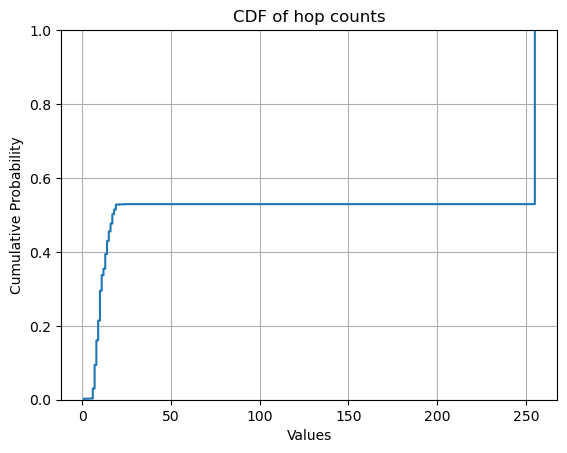

In [8]:
data_series = hops_by_trace_id['hop_number'].max()
plt.ecdf(data_series, label="Empirical CDF of hop count")

# Add styling and labels
plt.title("CDF of hop counts")
plt.xlabel("Values")
plt.ylabel("Cumulative Probability")
plt.grid(True)
# plt.legend()
plt.show()

Nearly half of our traceroutes didn't get a final reply

<Axes: >

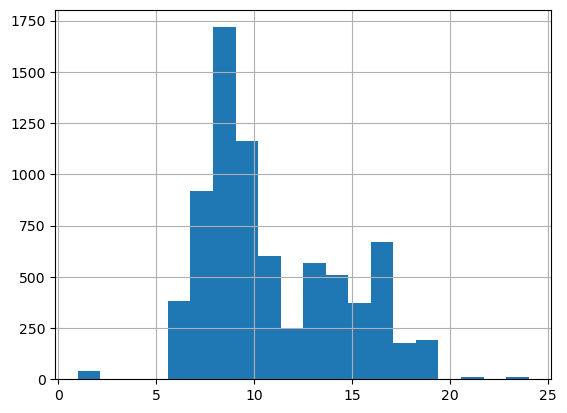

In [9]:
data_series[data_series < 255].hist(bins=20)

Most of our traces that get a final reply have a hop count between 6 and 11. There are a few very short paths, and a few long (> 20 hops) paths

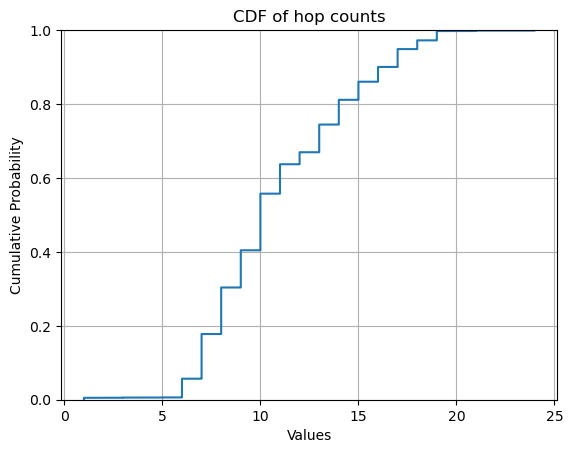

In [10]:
fin_data_series = data_series[data_series < 255]
plt.ecdf(fin_data_series, label="Empirical CDF of hop count for traces with final reply")

# Add styling and labels
plt.title("CDF of hop counts")
plt.xlabel("Values")
plt.ylabel("Cumulative Probability")
plt.grid(True)
# plt.legend()
plt.show()

What is that really short path?

In [11]:
df_max_hops = hops_by_trace_id['hop_number'].max().reset_index()
df_max_hops[df_max_hops['hop_number'] == 1]

,trace_id,hop_number
1139,1139,1
1146,1146,1
1153,1153,1
2567,2567,1
2574,2574,1
2581,2581,1
2588,2588,1
4001,4001,1
4008,4008,1
4015,4015,1


In [12]:
locations = df_max_hops[df_max_hops['hop_number'] == 1]['trace_id']
df_traces.loc[locations].merge(sites, left_on = 'site_id', right_on='site_id').merge(probes, left_on='probe_id', right_on='probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,1,2026,6,16,03:55:29,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
1,1,2026,6,16,04:10:36,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
2,1,2026,6,16,04:25:37,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
3,2,2026,6,16,03:43:31,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
4,2,2026,6,16,03:58:23,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
5,2,2026,6,16,04:13:26,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
6,2,2026,6,16,04:28:27,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
7,3,2026,6,16,03:46:43,+00:00,7764,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
8,3,2026,6,16,04:01:33,+00:00,7764,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
9,3,2026,6,16,04:16:43,+00:00,7764,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50


In [13]:
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


I checked one of the actual traces from my filtering application, and found that it had a "No destination" on the first hop. Need to filter that out.

In [14]:
df_hops

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
...,...,...,...,...
152014,14318,7,96.1,223.120.23.5
152015,14318,8,95.3,162.158.160.111
152016,14318,9,92.7,172.69.117.60
152017,14318,10,102.3,172.69.117.67


In [15]:
hops_by_trace_id.sample()

,trace_id,hop_number,hop_rtt,hop_ip
3,0,4,*,(no
14,1,7,*,(no
30,2,11,*,(no
40,3,9,*,(no
46,4,4,25.7,10.253.4.40
...,...,...,...,...
151981,14314,6,*,(no
151989,14315,6,*,(no
151995,14316,4,11.9,192.168.112.161
152002,14317,4,4.0,192.168.51.2


In [16]:
hops_by_trace_id['hop_number'] == '2'

False

In [17]:
max_indices = hops_by_trace_id['hop_number'].idxmax()

In [18]:
df_traces.index.dtype

dtype('int64')

In [19]:
max_indices

trace_id
0             7
1            19
2            31
3            42
4            56
          ...  
14314    151983
14315    151991
14316    151998
14317    152007
14318    152018
Name: hop_number, Length: 14319, dtype: int64

In [20]:
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


In [21]:
max_indices.index

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       14309, 14310, 14311, 14312, 14313, 14314, 14315, 14316, 14317, 14318],
      dtype='int64', name='trace_id', length=14319)

In [22]:
df_traces.loc[max_indices.index]

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


In [23]:
df_traces.loc[max_indices.index].merge(sites, on='site_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
...,...,...,...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce
14317,10,2026,6,16,14:15:05,+00:00,1016036,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce


In [24]:
max = hops_by_trace_id['hop_number'].max()

In [25]:
two_hop_trace_ids = max[max == 2].index

In [26]:
df_traces.loc[two_hop_trace_ids]

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
2019,2,2026,6,15,08:41:59,+00:00,60223,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc..."
3449,3,2026,6,15,08:43:37,+00:00,60223,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...


In [27]:
df_traces.loc[two_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,2,2026,6,15,08:41:59,+00:00,60223,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,nayatel.isb (AS23674),nayatel,Islamabad,isb,23674,154.192.10.60
1,3,2026,6,15,08:43:37,+00:00,60223,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,nayatel.isb (AS23674),nayatel,Islamabad,isb,23674,154.192.10.60


On June 15, 2026, the Nayatel probe traced dawn.com. On hop 1, no reply, on hop 2, reply from 192.168.18.1 with an RTT of 1.2ms. Same for the dunyanews.tv thing. At other times, we had a "no destination" for the dunya news website, and an 8 hop response for the dawn website.

In [28]:
three_hop_trace_ids = max[max == 3].index
df_traces.loc[three_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,7,2026,6,15,08:42:55,+00:00,60223,"45.60.109.176 - INCAPSULA - Incapsula Inc, US ...",HBL Bank,hbl.com,banking,nayatel.isb (AS23674),nayatel,Islamabad,isb,23674,154.192.10.60
1,7,2026,6,16,03:40:47,+00:00,7764,"45.60.109.176 - INCAPSULA - Incapsula Inc, US ...",HBL Bank,hbl.com,banking,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
2,9,2026,6,16,03:40:49,+00:00,7764,2.19.193.138 - AKAMAI-ASN1 - Akamai Internatio...,NADRA,nadra.gov.pk,government,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50


The HBL website was reachable from Nayatel ISB probe at a hop count of 3 on June 15, at 8:42 am with an RTT of 1.3 ms. But, at other times, it was reachable at a hop count of 19. HBL from LUMS Anchor also showed variations. Most of the time it got 255 TTL, but once, it got a three hop count 455.1 ms RTT, and once also got a 1 hop no destination reply. Similar behavior for NADRA website from the LUMS anchor.

In [29]:
four_hop_trace_ids = max[max == 4].index
df_traces.loc[four_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,10,2026,6,15,08:43:08,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce,nayatel.isb (AS23674),nayatel,Islamabad,isb,23674,154.192.10.60


On June 15, 8:43 am, Nayatel probe had three hop no replies, followed by a fourth hop response with an RTT of 1.4ms. At other times, it had an 8 hop count reply of around 3 ms. The sixth hop (172.31.5.106) always had an unusually high RTT.

In [30]:
five_hop_trace_ids = max[max == 5].index
df_traces.loc[five_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,1,2026,6,16,03:40:36,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe (AS17557),ptcl,Lahore,lhe,17557,203.135.63.50
1,6,2026,6,15,08:41:32,+00:00,60223,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,nayatel.isb (AS23674),nayatel,Islamabad,isb,23674,154.192.10.60


The Daraz five hop trace had a "no destination". The Geo trace had four hop no replies, followed by a fifth hop reached. At other times, the trace was 8 hops.

In [31]:
six_hop_trace_ids = max[max == 6].index
df_traces.loc[six_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,2,2026,6,14,14:30:06,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
1,2,2026,6,14,14:45:13,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
2,2,2026,6,14,15:00:14,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
3,2,2026,6,14,15:15:16,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
4,2,2026,6,14,15:30:14,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,6,2026,6,16,13:14:05,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
380,6,2026,6,16,13:29:02,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
381,6,2026,6,16,13:44:04,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16
382,6,2026,6,16,13:59:02,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe (AS152605),zcom,Lahore,lhe,152605,157.20.147.16


There are a lot of these, so these might be mostly legitimate. 

It appears that all paths with a hop count of less than six are erroneous data values.

In [32]:
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


In [33]:
df_hops

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
...,...,...,...,...
152014,14318,7,96.1,223.120.23.5
152015,14318,8,95.3,162.158.160.111
152016,14318,9,92.7,172.69.117.60
152017,14318,10,102.3,172.69.117.67


In [36]:
# max_hop_num_for_trace = df_hops[df_hops['trace_id'] == 0]['hop_number'].max()
max_hop_indices = df_hops.groupby('trace_id')['hop_number'].idxmax()
df_max_hops = df_hops.loc[max_hop_indices]

In [37]:
df_max_hops

,trace_id,hop_number,hop_rtt,hop_ip
7,0,255,104.2,47.246.167.168
19,1,255,180.1,47.246.167.168
31,2,12,80.7,47.246.167.168
42,3,255,98.4,47.246.167.168
56,4,255,116.7,47.246.167.168
...,...,...,...,...
151983,14314,255,97.7,172.67.195.207
151991,14315,255,*,(no
151998,14316,7,4.8,172.67.195.207
152007,14317,9,23.2,172.67.195.207


In [44]:
timed_out_ids = df_max_hops[df_max_hops['hop_ip'] == '(no']['trace_id']
timed_out_ids

98            8
642          56
823          72
913          80
1186        104
          ...  
151674    14280
151738    14287
151802    14294
151930    14308
151991    14315
Name: trace_id, Length: 3606, dtype: int64

In [46]:
df_traces['is_timeout'] = df_traces.index.isin(timed_out_ids)
df_traces.sample(20)

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout
trace_id,,,,,,,,,
11484,9,2026,6,14,15:11:53,+00:00,1016036,2.19.193.138 - AKAMAI-ASN1 - Akamai Internatio...,False
14211,10,2026,6,16,10:30:01,+00:00,1016036,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
1064,1,2026,6,16,01:13:29,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
13555,10,2026,6,15,11:14:56,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
258,1,2026,6,14,22:26:10,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
7962,6,2026,6,15,15:56:39,+00:00,60223,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",False
2047,2,2026,6,15,09:30:21,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",False
9985,7,2026,6,16,12:59:54,+00:00,1016036,"45.60.109.176 - INCAPSULA - Incapsula Inc, US ...",False
3127,3,2026,6,14,22:31:37,+00:00,7764,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,True


In [47]:
df_traces.loc[8]

site_id                                                       1
year                                                       2026
month                                                         6
day                                                          14
time                                                   14:40:30
timezone                                                 +00:00
probe_id                                                   7764
dest          47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
is_timeout                                                 True
Name: 8, dtype: object

In [48]:
df_traces[df_traces['is_timeout'] == False]

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout
trace_id,,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
...,...,...,...,...,...,...,...,...,...
14313,10,2026,6,16,14:12:57,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False


<Axes: xlabel='site_id', ylabel='probe_id'>

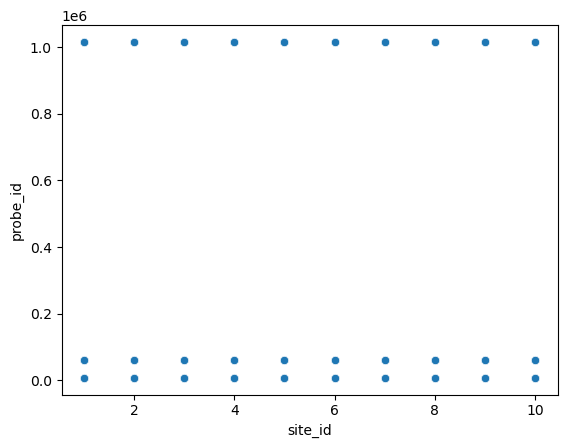

In [52]:
import seaborn as sns
sns.scatterplot(df_traces[['site_id', 'probe_id', 'is_timeout']], x = df_traces['site_id'], y=df_traces['probe_id'])

In [53]:
df_traces[df_traces['is_timeout']]['probe_id'].unique()

array([   7764, 1016036,    7613,   62224,   60223, 1016143, 1015679,
       1016126])

In [54]:
df_traces[df_traces['is_timeout']]['site_id'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

The above shows the timeouts happened from all probes at different times and for all sites, so not one is to blame.

In [55]:
untimed_out_traces = df_traces[df_traces['is_timeout'] == False]

In [56]:
max_hop_indices

trace_id
0             7
1            19
2            31
3            42
4            56
          ...  
14314    151983
14315    151991
14316    151998
14317    152007
14318    152018
Name: hop_number, Length: 14319, dtype: int64

In [69]:
max_hop_values = df_hops.groupby('trace_id')['hop_number'].max()
max_hop_values
# max_hop_df = max_hop_values.to_frame(name='max_hops')

trace_id
0        255
1        255
2         12
3        255
4        255
        ... 
14314    255
14315    255
14316      7
14317      9
14318     11
Name: hop_number, Length: 14319, dtype: int64

In [74]:
df_hops[df_hops['trace_id'] == 0]

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
5,0,6,*,(no
6,0,7,*,(no
7,0,255,104.2,47.246.167.168


In [67]:
df_traces = df_traces.merge(max_hop_df, left_index = True, right_index = True, how='left')
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
...,...,...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,255
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",True,255
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,7


In [68]:
df_complete_traces = df_traces[df_traces['is_timeout'] == False]
df_complete_traces

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
...,...,...,...,...,...,...,...,...,...,...
14313,10,2026,6,16,14:12:57,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,8
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,255
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,7


In [76]:
df_complete_traces_true_hops = df_complete_traces[df_complete_traces['max_hops'] < 255]
df_complete_traces_true_hops

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
11,1,2026,6,14,14:43:35,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,11
17,1,2026,6,14,14:56:04,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
19,1,2026,6,14,14:58:36,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,11
20,1,2026,6,14,14:58:36,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,14
...,...,...,...,...,...,...,...,...,...,...
14312,10,2026,6,16,14:12:04,+00:00,7613,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,10
14313,10,2026,6,16,14:12:57,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,8
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,7


Site ID 10 for probe ID 1015679, June 14 3 pm to 6 pm, then 6 pm to June 15 12 pm. June 15 2 pm to 6 pm.

In [82]:
site_id = 10
probe_id = 1015679
mask = (df_complete_traces_true_hops['site_id'] == site_id) & (df_complete_traces_true_hops['probe_id'] == 1015679)
case1_traces = df_complete_traces_true_hops[mask]
case1_traces

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
12894,10,2026,6,14,14:31:28,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12901,10,2026,6,14,14:46:29,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12909,10,2026,6,14,15:01:19,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12918,10,2026,6,14,15:16:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12925,10,2026,6,14,15:31:23,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
...,...,...,...,...,...,...,...,...,...,...
14289,10,2026,6,16,13:16:30,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
14297,10,2026,6,16,13:31:31,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
14303,10,2026,6,16,13:46:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11


In [94]:
spike1 = case1_traces[(case1_traces['day'] == 14) & (case1_traces['time'] >= "15:00:00") & (case1_traces['time'] <= "18:00:00")]

In [89]:
non_spike = case1_traces[(case1_traces.index > 12997) & (case1_traces['day'] == 15) & (case1_traces['time'] <= '18:00:00')]
non_spike

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
13197,10,2026,6,15,00:01:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13206,10,2026,6,15,00:16:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13214,10,2026,6,15,00:31:33,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13222,10,2026,6,15,00:46:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13229,10,2026,6,15,01:01:28,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
...,...,...,...,...,...,...,...,...,...,...
13716,10,2026,6,15,16:46:31,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13722,10,2026,6,15,17:01:20,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13729,10,2026,6,15,17:16:20,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11


In [92]:
df_hops

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
...,...,...,...,...
152014,14318,7,96.1,223.120.23.5
152015,14318,8,95.3,162.158.160.111
152016,14318,9,92.7,172.69.117.60
152017,14318,10,102.3,172.69.117.67


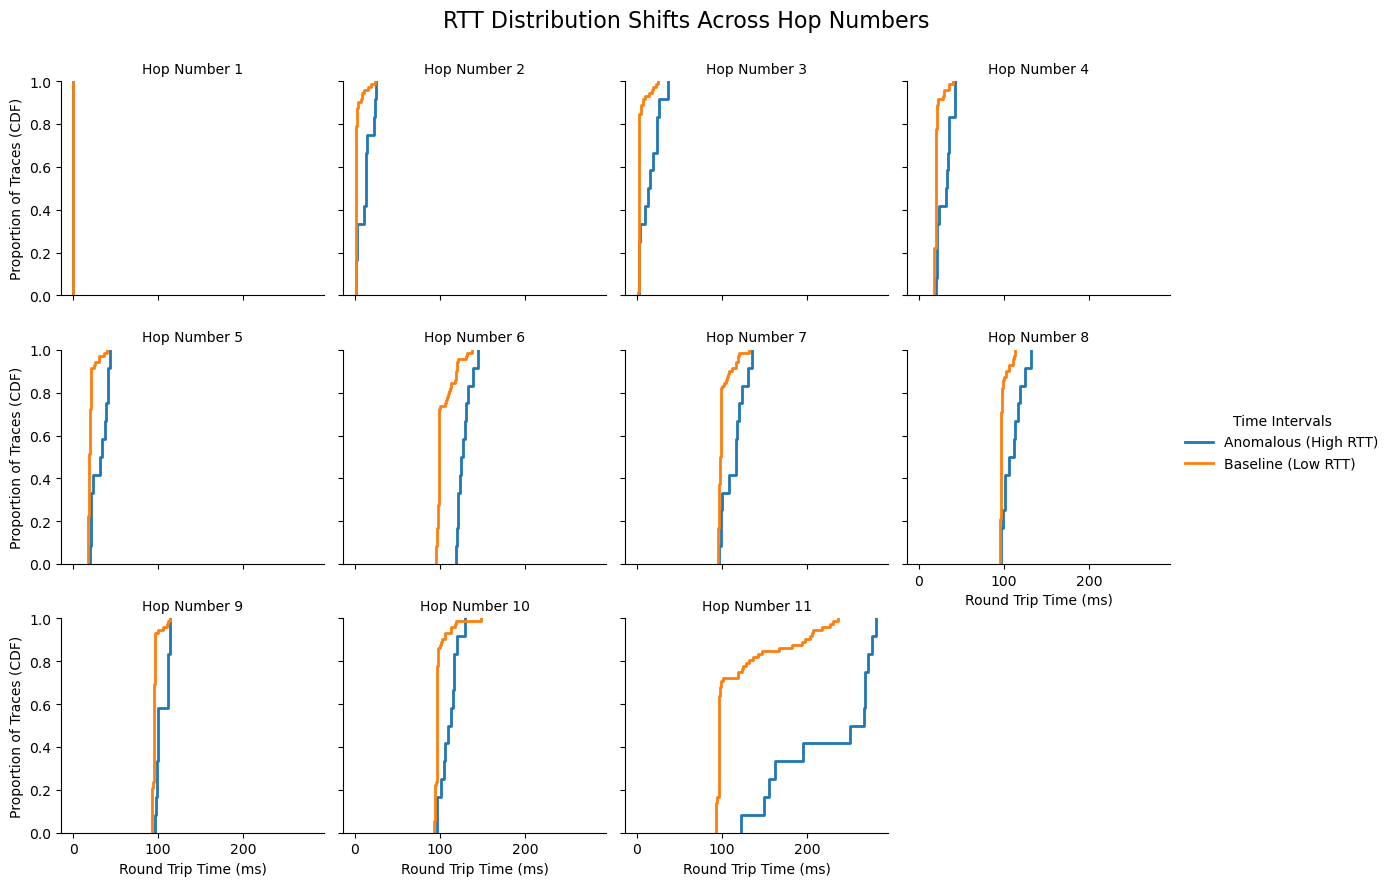

In [98]:
ids_interval_1 = spike1.index
ids_interval_2 = non_spike.index
df_hops['hop_num_rtt'] = pd.to_numeric(df_hops['hop_rtt'], errors='coerce')

hops_int1 = df_hops[df_hops['trace_id'].isin(ids_interval_1)].copy()

hops_int2 = df_hops[df_hops['trace_id'].isin(ids_interval_2)].copy()

hops_int2['Interval'] = 'Baseline (Low RTT)'
hops_int1['Interval'] = 'Anomalous (High RTT)'

df_analysis = pd.concat([hops_int1, hops_int2], ignore_index=True)
df_plot = df_analysis.dropna(subset=['hop_num_rtt']).copy()

g = sns.FacetGrid(df_plot, col="hop_number", hue="Interval", 
                  col_wrap=4, height=3, sharex=True, sharey=True)

# Map an empirical CDF plot onto each facet
g.map(sns.ecdfplot, "hop_num_rtt", linewidth=2)

# Styling adjustments
g.add_legend(title="Time Intervals")
g.set_axis_labels("Round Trip Time (ms)", "Proportion of Traces (CDF)")
g.set_titles("Hop Number {col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle("RTT Distribution Shifts Across Hop Numbers", fontsize=16)

plt.show()

/var/folders/5v/028m2x5n3_xdf198s5vqk0000000gn/T/ipykernel_12248/2075936615.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1.2' '0.7' '1.2' ... '1.3' '0.7' '0.3']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_hops.loc[hop_1_mask, 'per_hop_contribution'] = df_hops.loc[hop_1_mask, 'hop_rtt']


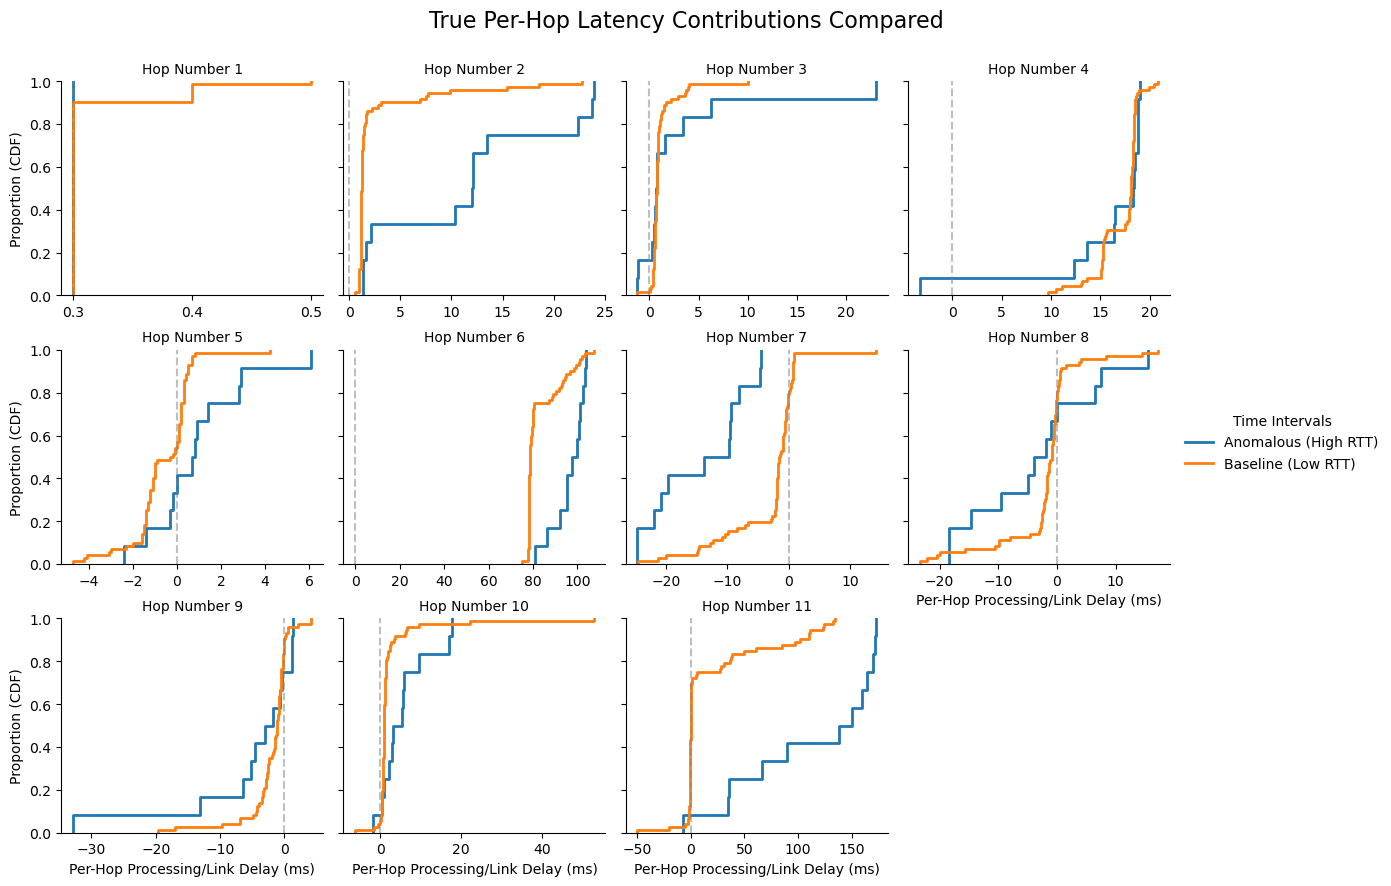

In [100]:
# 1. Clean the column to float numbers (converting '*' to NaN)
# df_hops['hop_rtt'] = pd.to_numeric(df_hops['hop_rtt'], errors='coerce')

# 2. Crucial: Sort by trace and hop sequence so the math aligns perfectly
df_hops = df_hops.sort_values(by=['trace_id', 'hop_number'])

# 3. Compute the incremental delay (Hop N RTT - Hop N-1 RTT)
df_hops['per_hop_contribution'] = df_hops.groupby('trace_id')['hop_num_rtt'].diff()

# 4. Handle Hop 1: Since Hop 1 has no previous hop, .diff() leaves it as NaN.
# But Hop 1's cumulative RTT *is* its per-hop contribution!
hop_1_mask = df_hops['hop_number'] == 1
df_hops.loc[hop_1_mask, 'per_hop_contribution'] = df_hops.loc[hop_1_mask, 'hop_rtt']

ids_interval_1 = spike1.index
ids_interval_2 = non_spike.index

# Extract segments
hops_int1 = df_hops[df_hops['trace_id'].isin(ids_interval_1)].copy()
hops_int2 = df_hops[df_hops['trace_id'].isin(ids_interval_2)].copy()

# Label intervals
hops_int2['Interval'] = 'Baseline (Low RTT)'
hops_int1['Interval'] = 'Anomalous (High RTT)'

# Combine and drop NaNs (which include drops and missing structural elements)
df_analysis = pd.concat([hops_int1, hops_int2], ignore_index=True)
df_plot = df_analysis.dropna(subset=['per_hop_contribution']).copy()

g = sns.FacetGrid(df_plot, col="hop_number", hue="Interval", 
                  col_wrap=4, height=3, sharex=False, sharey=True)

# Map the Empirical CDF using the per-hop column
g.map(sns.ecdfplot, "per_hop_contribution", linewidth=2)

# Styling adjustments
g.add_legend(title="Time Intervals")
g.set_axis_labels("Per-Hop Processing/Link Delay (ms)", "Proportion (CDF)")
g.set_titles("Hop Number {col_name}")

# Set a reasonable x-axis limit if negative/positive outliers stretch the graph
for ax in g.axes.flatten():
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5) # Mark 0ms reference

plt.subplots_adjust(top=0.9)
g.fig.suptitle("True Per-Hop Latency Contributions Compared", fontsize=16)

plt.show()

In [105]:
spike1

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
12909,10,2026,6,14,15:01:19,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12918,10,2026,6,14,15:16:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12925,10,2026,6,14,15:31:23,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12933,10,2026,6,14,15:46:20,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12941,10,2026,6,14,16:01:24,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12950,10,2026,6,14,16:16:29,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12957,10,2026,6,14,16:31:24,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12966,10,2026,6,14,16:46:30,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12974,10,2026,6,14,17:01:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
